<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/assg_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
data = pd.read_csv('/content/drive/MyDrive/Breast_Cancer_Wisconsin_Dataset.csv')

## **question-1: find the tree depth and highest accuracy**

In [44]:
print("Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)")

# Convert diagnosis to numbers
data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})
important_features=[
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se',
    'texture_se',
]
# Create simple dataset
X = data[important_features]
y = data['diagnosis_numeric']

print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")

Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)
X (measurements): (569, 6)
y (diagnosis): (569,)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test)} patients (computer will be tested on these)")

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)


In [67]:
# Create our Skill Morph model
skillmorph_doctor = DecisionTreeClassifier(
    max_depth=3,
    random_state=20
)

print("Teaching Skill Morph doctor with training data...")
# Train the model
skillmorph_doctor.fit(X_train, y_train)
print("Skill Morph doctor training completed!")


Teaching Skill Morph doctor with training data...
Skill Morph doctor training completed!


In [68]:

print("Now let's see how good our Skill Morph doctor is...")

# Make predictions
predictions = skillmorph_doctor.predict(X_test)

print("Skill Morph doctor made predictions for all test patients!")


# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nSkill Morph Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

Now let's see how good our Skill Morph doctor is...
Skill Morph doctor made predictions for all test patients!

Skill Morph Doctor Accuracy: 0.895 (89.5%)


## **question-2: confusion matrix, calculate precision,recall,f1-score**

Confusion Matrix:
[[58  8]
 [ 4 44]]

Correct: 102
Wrong: 12


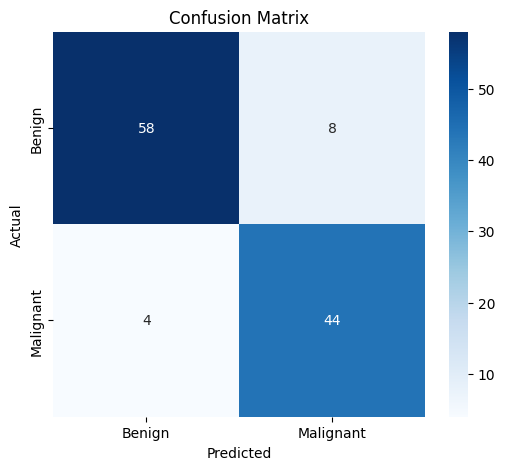

In [60]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Print it
print("Confusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"Wrong: {cm[0,1] + cm[1,0]}")

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [62]:

precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

Precision: 0.85
Recall:    0.92
F1-Score:  0.88
